Data Acquisition and Initial Preprocessing

In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"imrohitnath","key":"6de3afcb4caaff8744afe4773e1852cd"}'}

In [3]:
!kaggle datasets download mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 156MB/s]



In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("creditcard.csv")

In [ ]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
85003,60557.0,-4.003131,3.432683,-0.671565,-0.572105,-0.993823,-0.761333,0.120367,0.829239,2.064841,...,-0.748901,-0.793027,0.080643,-0.046641,0.220091,-0.034208,-0.363793,-1.068771,17.99,0
107429,70431.0,0.497070,-1.541075,0.855076,0.561485,-1.601774,-0.015608,-0.350250,0.144121,1.302540,...,0.005993,-0.501683,-0.132658,0.462162,-0.139715,0.920077,-0.087037,0.070224,343.55,0
208330,137073.0,2.311804,-1.587795,-1.145236,-1.874239,-0.947411,0.252960,-1.449457,0.095749,-1.044026,...,-0.185320,-0.081642,0.091983,-1.493195,-0.181833,-0.102294,0.016572,-0.070367,20.80,0
106993,70225.0,-0.391842,0.004669,0.953340,-1.949281,0.327288,0.296404,-0.126392,0.256948,-1.349564,...,0.209886,0.408979,-0.029930,-1.107027,-0.564597,-0.508585,0.174456,0.175176,37.35,0
202482,134349.0,-1.014219,0.522775,-0.337978,-1.957797,3.578395,3.266965,0.602857,0.644645,-0.305879,...,0.147742,0.590740,-0.680551,0.745346,1.119496,0.013520,0.004530,-0.132643,6.00,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
df = df.dropna()

In [ ]:
print(df.duplicated().sum())

1081


In [9]:
df = df.drop_duplicates()

In [10]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998333
1,0.001667


EDA

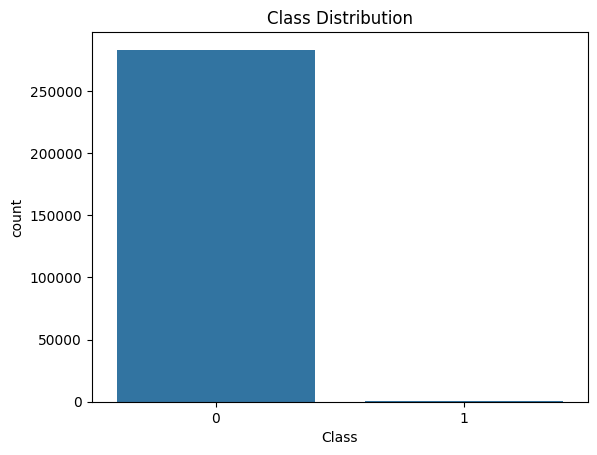

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

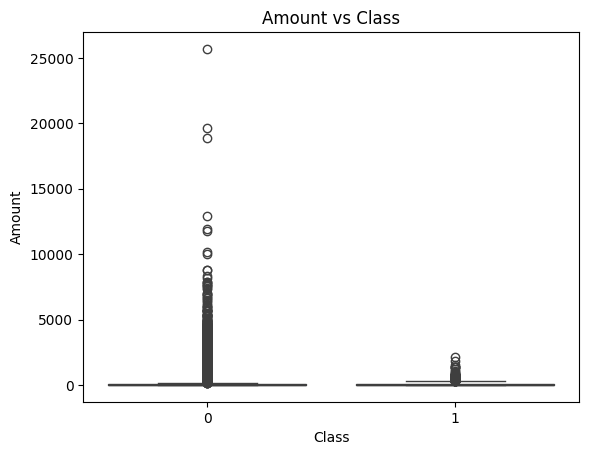

In [ ]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Class")
plt.show()

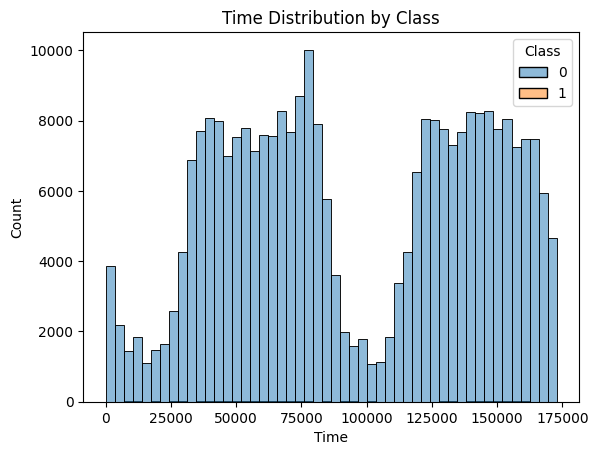

In [ ]:
sns.histplot(data=df, x='Time', hue='Class', bins=50)
plt.title("Time Distribution by Class")
plt.show()

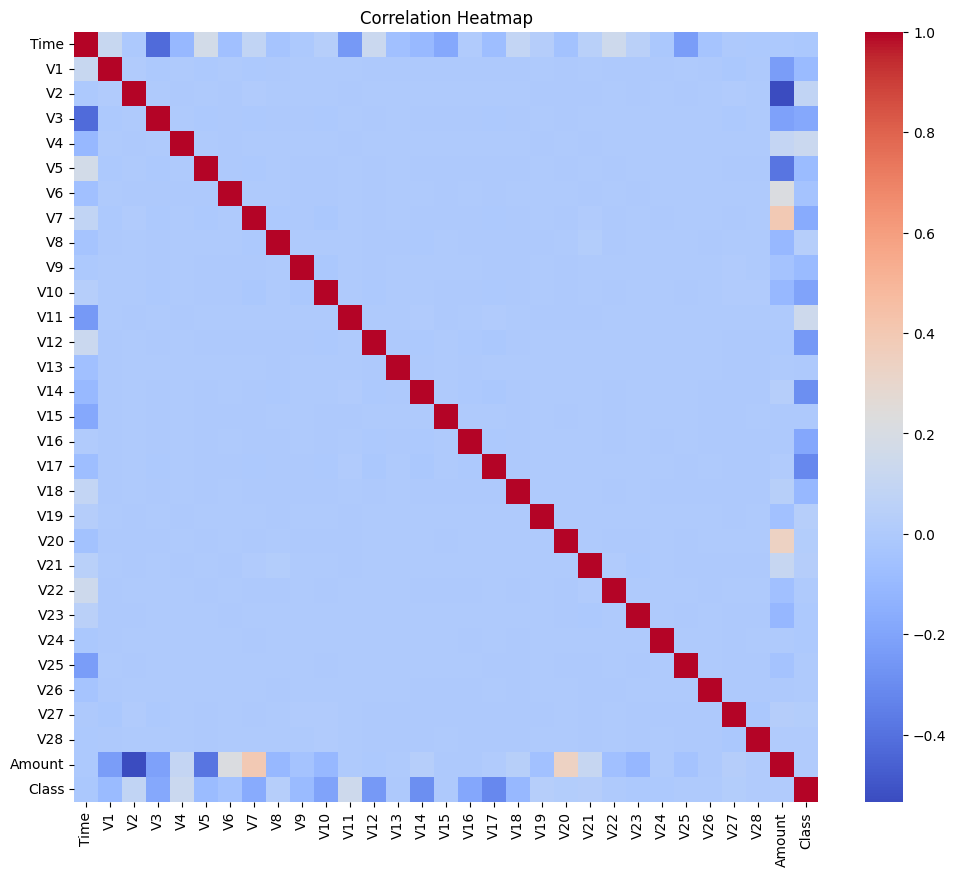

In [ ]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Train-Test Split and Feature Scaling

In [11]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# Scaling only numerical features (Amount, Time)

scaler = StandardScaler()

X_train[['Amount','Time']] = scaler.fit_transform(X_train[['Amount','Time']])
X_test[['Amount','Time']] = scaler.transform(X_test[['Amount','Time']])

Handling Class Imbalance using SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply SMOTE ONLY on training data to avoid data leakage
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check balance
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_resampled.value_counts())

Before SMOTE:
 Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
 Class
0    226602
1    226602
Name: count, dtype: int64


Baseline Model: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55169  1482]
 [   12    83]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [ ]:
# Evaluating different decision thresholds for better precision-recall tradeoff

y_proba = lr.predict_proba(X_test)[:, 1]

In [ ]:
for t in [0.5, 0.7, 0.8, 0.9, 0.95]:
    y_pred_new = (y_proba > t).astype(int)
    print("Threshold:", t)
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))

Threshold: 0.5
[[55169  1482]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

Threshold: 0.7
[[55905   746]
 [   13    82]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.10      0.86      0.18        95

    accuracy                           0.99     56746
   macro avg       0.55      0.92      0.59     56746
weighted avg       1.00      0.99      0.99     56746

Threshold: 0.8
[[56174   477]
 [   14    81]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.15      0.85      0.25        95

    accuracy                           0.99 

Advanced Model: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Training a non-linear ensemble model for better performance on complex patterns

rf = RandomForestClassifier(random_state=42)

In [ ]:
rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred_rf)
classification_report(y_test, y_pred_rf)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00     56651\n           1       0.91      0.76      0.83        95\n\n    accuracy                           1.00     56746\n   macro avg       0.96      0.88      0.91     56746\nweighted avg       1.00      1.00      1.00     56746\n'

In [ ]:
y_proba_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
for t in [0.5, 0.7, 0.8, 0.9, 0.95]:
    y_pred_new = (y_proba_rf > t).astype(int)
    print("Threshold:", t)
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))

Threshold: 0.5
[[56644     7]
 [   23    72]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Threshold: 0.7
[[56649     2]
 [   27    68]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Threshold: 0.8
[[56650     1]
 [   30    65]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.98      0.68      0.81        95

    accuracy                           1.00 

### Key Observations

- The dataset is highly imbalanced (fraud cases are extremely rare)
- Accuracy is not a reliable metric in this scenario
- Focus should be on **precision, recall, and F1-score** for the fraud class
- Improving recall helps detect more frauds, while precision reduces false alarms

Additional Models with Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
X_sample = X_train_resampled.sample(50000, random_state=42)
y_sample = y_train_resampled.loc[X_sample.index]

In [ ]:
param_et = {
    'n_estimators': [100, 150],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

param_hgb = {
    'max_iter': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [None, 10]
}

In [ ]:
models = {
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "HistGB": HistGradientBoostingClassifier()
}

param_grids = {
    "ExtraTrees": param_et,
    "HistGB": param_hgb
}

In [ ]:
best_models = {}

for name in models:
    print(f"\nTraining {name}...\n")

    search = RandomizedSearchCV(
        models[name],
        param_distributions=param_grids[name],
        n_iter=3,
        cv=2,
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_sample, y_sample)

    best_model = search.best_estimator_
    best_models[name] = best_model

    print("Best Params:", search.best_params_)

    y_pred = best_model.predict(X_test)

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Training ExtraTrees...

Best Params: {'n_estimators': 150, 'min_samples_split': 2, 'max_depth': None}
[[56617    34]
 [   20    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.69      0.79      0.74        95

    accuracy                           1.00     56746
   macro avg       0.84      0.89      0.87     56746
weighted avg       1.00      1.00      1.00     56746


Training HistGB...

Best Params: {'max_iter': 150, 'max_depth': None, 'learning_rate': 0.1}
[[56580    71]
 [   17    78]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.52      0.82      0.64        95

    accuracy                           1.00     56746
   macro avg       0.76      0.91      0.82     56746
weighted avg       1.00      1.00      1.00     56746



Ensemble Learning using Voting Classifier

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('et', best_models['ExtraTrees'])
    ],
    voting='soft'
)

voting_clf.fit(X_train_resampled, y_train_resampled)
y_pred_vote = voting_clf.predict(X_test)

print(confusion_matrix(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))

### Final Model Selection

- Random Forest performed best in terms of overall balance between precision and recall
- It achieved a strong F1-score for the fraud class
- It also produced very few false positives compared to other models

Therefore, Random Forest is selected as the final model for deployment.

Model Serialization and Export

In [15]:
import joblib
from google.colab import files

# define threshold
best_threshold = 0.5

# save everything
joblib.dump(rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(best_threshold, "threshold.pkl")
joblib.dump(X_train.mean(), "default_input.pkl")

# download
files.download("rf_model.pkl")
files.download("scaler.pkl")
files.download("threshold.pkl")
files.download("default_input.pkl")

NameError: name 'rf' is not defined

In [ ]:
import joblib
from google.colab import files

joblib.dump(X_train.mean(), "default_input.pkl")

# download
files.download("rf_model.pkl")
files.download("scaler.pkl")
files.download("threshold.pkl")
files.download("default_input.pkl")

### Conclusion

- Developed a robust fraud detection pipeline with appropriate preprocessing and model evaluation  
- Achieved strong performance using Random Forest with balanced precision and recall  

- Additional improvements are possible with more extensive tuning, but were not pursued due to high training time